In [1]:
# Cell 1 - Imports
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import cv2
from torchvision import models, transforms
from pathlib import Path
from PIL import Image
import json
import sys

sys.path.append(str(Path("..").resolve() / "model"))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Using device: {device}")

✅ Using device: cuda


In [2]:
# Cell 2 - Load model
BASE_DIR = Path("..").resolve()

with open(BASE_DIR / "utils" / "dataset_info.json", "r") as f:
    dataset_info = json.load(f)

NUM_CLASSES = dataset_info["num_classes"]
CLASS_NAMES = dataset_info["class_names"]

class SkinDiseaseModel(nn.Module):
    def __init__(self, num_classes):
        super(SkinDiseaseModel, self).__init__()
        self.backbone = models.efficientnet_b0(weights='DEFAULT')
        for param in list(self.backbone.parameters())[:-20]:
            param.requires_grad = False
        num_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Identity()
        self.disease_head = nn.Sequential(
            nn.Linear(num_features, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )
        self.severity_head = nn.Sequential(
            nn.Linear(num_features, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 3)
        )
    def forward(self, x):
        features     = self.backbone(x)
        disease_out  = self.disease_head(features)
        severity_out = self.severity_head(features)
        return disease_out, severity_out

model = SkinDiseaseModel(num_classes=NUM_CLASSES).to(device)
model.load_state_dict(
    torch.load(BASE_DIR / "checkpoints" / "best_model.pth",
               map_location=device)
)
model.eval()
print("✅ Model loaded!")

C:\Users\shruti\AppData\Local\Temp\ipykernel_16740\4016939723.py:38: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(BASE_DIR / "checkpoints" / "best_model.pth",


✅ Model loaded!


In [3]:
# Cell 3 - Grad-CAM implementation
class GradCAM:
    def __init__(self, model):
        self.model = model
        self.gradients = None
        self.activations = None
        
        # Hook into last conv layer of EfficientNet
        target_layer = model.backbone.features[-1]
        
        # Forward hook - save activations
        def forward_hook(module, input, output):
            self.activations = output.detach()
        
        # Backward hook - save gradients
        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0].detach()
        
        target_layer.register_forward_hook(forward_hook)
        target_layer.register_full_backward_hook(backward_hook)
    
    def generate(self, image_tensor, class_idx=None):
        self.model.zero_grad()
        
        # Forward pass
        image_tensor.requires_grad_(True)
        disease_out, _ = self.model(image_tensor)
        
        # Use predicted class if not specified
        if class_idx is None:
            class_idx = disease_out.argmax().item()
        
        # Backward pass
        score = disease_out[0, class_idx]
        score.backward()
        
        # Generate heatmap
        gradients   = self.gradients[0]
        activations = self.activations[0]
        
        # Pool gradients
        weights = gradients.mean(dim=(1, 2))
        
        # Weighted combination
        cam = torch.zeros(activations.shape[1:], device=device)
        for i, w in enumerate(weights):
            cam += w * activations[i]
        
        # ReLU and normalize
        cam = torch.relu(cam)
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)
        
        return cam.cpu().numpy(), class_idx

print("✅ Grad-CAM class defined!")

✅ Grad-CAM class defined!


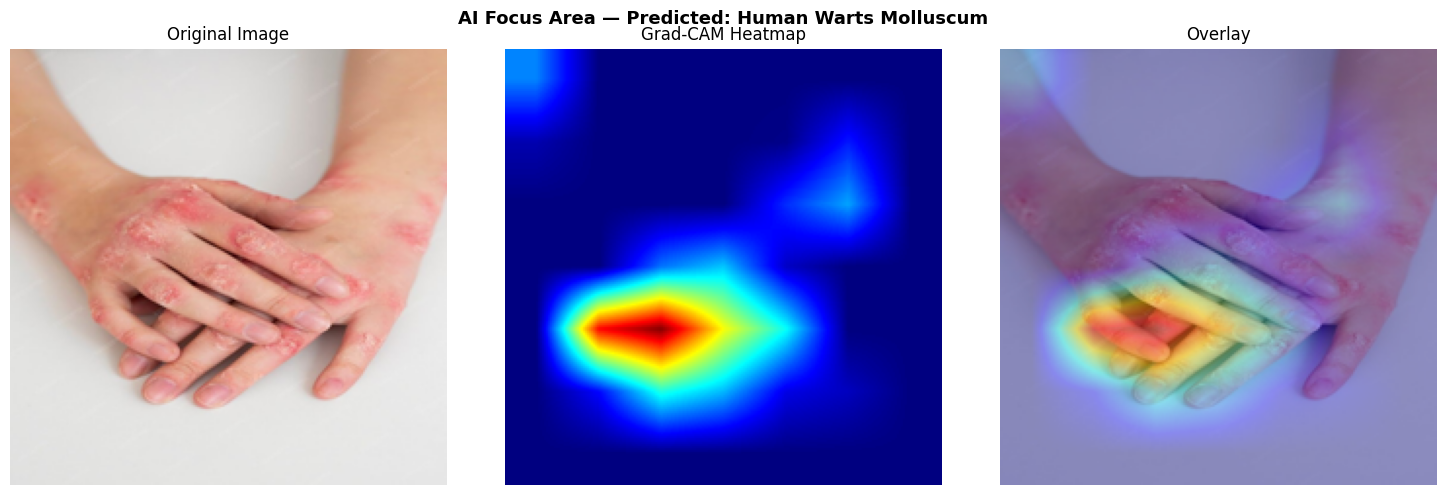

✅ Grad-CAM generated!
   Predicted: Human Warts Molluscum


In [4]:
# Cell 4 - Generate heatmap
def preprocess_image(image_path):
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])
    image = Image.open(image_path).convert("RGB")
    return image, transform(image).unsqueeze(0)

def show_gradcam(image_path):
    # Load and preprocess image
    original_image, image_tensor = preprocess_image(image_path)
    image_tensor = image_tensor.to(device)
    
    # Generate Grad-CAM
    gradcam = GradCAM(model)
    cam, class_idx = gradcam.generate(image_tensor)
    
    # Resize heatmap to image size
    cam_resized = cv2.resize(cam, (224, 224))
    
    # Convert to heatmap
    heatmap = cv2.applyColorMap(
        np.uint8(255 * cam_resized), 
        cv2.COLORMAP_JET
    )
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    
    # Overlay on original image
    original_array = np.array(
        original_image.resize((224, 224))
    )
    overlay = cv2.addWeighted(
        original_array, 0.6,
        heatmap, 0.4, 0
    )
    
    # Plot
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    axes[0].imshow(original_array)
    axes[0].set_title("Original Image", fontsize=12)
    axes[0].axis('off')
    
    axes[1].imshow(heatmap)
    axes[1].set_title("Grad-CAM Heatmap", fontsize=12)
    axes[1].axis('off')
    
    axes[2].imshow(overlay)
    axes[2].set_title("Overlay", fontsize=12)
    axes[2].axis('off')
    
    disease_name = CLASS_NAMES[class_idx].replace("_", " ").title()
    plt.suptitle(
        f"AI Focus Area — Predicted: {disease_name}",
        fontsize=13,
        fontweight='bold'
    )
    plt.tight_layout()
    plt.savefig(str(BASE_DIR / "reports" / "gradcam_sample.png"))
    plt.show()
    print(f"✅ Grad-CAM generated!")
    print(f"   Predicted: {disease_name}")

# Test with your image
show_gradcam(BASE_DIR / "test_image.jpg")

In [6]:
# Cell 5 - Save gradcam.py to model folder
gradcam_code = '''import torch
import torch.nn as nn
import numpy as np
import cv2
from pathlib import Path

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class GradCAM:
    def __init__(self, model):
        self.model      = model
        self.gradients  = None
        self.activations = None
        target_layer    = model.backbone.features[-1]
        
        def forward_hook(module, input, output):
            self.activations = output.detach()
        
        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0].detach()
        
        target_layer.register_forward_hook(forward_hook)
        target_layer.register_full_backward_hook(backward_hook)
    
    def generate(self, image_tensor, class_idx=None):
        self.model.zero_grad()
        image_tensor.requires_grad_(True)
        disease_out, _ = self.model(image_tensor)
        
        if class_idx is None:
            class_idx = disease_out.argmax().item()
        
        score = disease_out[0, class_idx]
        score.backward()
        
        gradients   = self.gradients[0]
        activations = self.activations[0]
        weights     = gradients.mean(dim=(1, 2))
        
        cam = torch.zeros(activations.shape[1:], device=device)
        for i, w in enumerate(weights):
            cam += w * activations[i]
        
        cam = torch.relu(cam)
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)
        
        return cam.cpu().numpy(), class_idx

def get_heatmap(image, model):
    from torchvision import transforms
    from PIL import Image
    import numpy as np
    
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])
    
    if isinstance(image, str):
        image = Image.open(image).convert("RGB")
    
    image_tensor = transform(image).unsqueeze(0).to(device)
    
    gradcam = GradCAM(model)
    cam, _  = gradcam.generate(image_tensor)
    
    cam_resized = cv2.resize(cam, (224, 224))
    heatmap     = cv2.applyColorMap(
        np.uint8(255 * cam_resized),
        cv2.COLORMAP_JET
    )
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    
    original_array = np.array(image.resize((224, 224)))
    overlay = cv2.addWeighted(
        original_array, 0.6,
        heatmap, 0.4, 0
    )
    
    return overlay
'''

save_path = Path("..").resolve() / "model" / "gradcam.py"
with open(save_path, "w") as f:
    f.write(gradcam_code)

print(f"✅ gradcam.py saved to {save_path}")
print("🎉 Grad-CAM Notebook Complete!")

✅ gradcam.py saved to C:\Users\shruti\Desktop\project\Skin-Disease Predictor\model\gradcam.py
🎉 Grad-CAM Notebook Complete!
